In [9]:
data

,89Y-Collagen-I mean,142Nd-CA9 mean,143Nd-Vimentin mean,144Nd-CD14 mean,145Nd-CD31 mean,146Nd-CD11b mean,147Sm-CD163 mean,148Nd-Pan-Keratin mean,149Sm-CD15 mean,150Nd-CD274 mean,...,172Yb-S100A2 std,173Yb-CD45RO std,174Yb-Keratin_8_18 std,176Yb-Histone_H3 std,191Ir-DNA1 std,193Ir-DNA2 std,195Pt-ICSK1 std,196Pt-ICSK2 std,198Pt-ICSK3 std,209Bi-aSMA std
0,0.00,0.200000,0.442000,0.530600,0.0000,0.0,0.0,8.014700,0.0,0.000000,...,0.0,0.489898,6.863593,2.766985,1.670161,3.612222,1.879606,2.995956,12.270987,0.400000
1,0.20,0.000000,2.887200,0.130600,0.3429,0.0,0.0,1.179800,0.0,0.000000,...,0.0,0.000000,2.561592,1.929779,1.199460,3.087290,1.429781,1.254018,2.014315,2.974960
2,0.20,0.000000,2.687200,0.130600,0.3429,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,2.357432,1.402180,2.551714,0.848777,1.397306,1.948319,2.834323
3,0.25,0.930625,1.249250,0.000000,0.0000,0.0,0.0,1.905625,0.0,0.000000,...,0.0,0.000000,2.461509,0.775838,0.638657,1.188033,2.439257,1.632586,2.672229,5.268774
4,0.00,0.400000,0.300000,0.221300,0.0000,0.0,0.0,9.972200,0.0,0.200000,...,0.0,0.200000,13.403846,1.826562,0.435041,0.742698,1.157963,2.223416,5.187187,1.833972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543082,0.00,0.200000,1.730100,0.380400,0.0000,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,2.632070,1.594976,3.033596,0.513971,1.868767,0.502012,1.503128
543083,0.00,0.000000,2.144750,0.000000,0.0000,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,5.310116,3.017322,5.390552,0.784038,0.901653,0.804423,3.167084
543084,0.00,0.000000,1.479917,0.166667,0.0000,0.0,0.0,0.000000,0.0,0.166667,...,0.0,0.000000,0.000000,4.683343,1.353049,2.384861,0.720311,1.208540,0.656616,0.817437
543085,0.00,0.166667,1.448417,0.483667,0.0000,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,1.720089,3.377057,5.408820,0.415064,1.729834,0.716092,1.547892


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from mosna import mosna

#récup les stats par nodes dans un fichier sans cacluler dans fichier
file_name = 'aggregation_statistics_new.parquet'
save_dir = Path("./OUTPUT/niches/agreg")
var_aggreg = pd.read_parquet(save_dir / file_name)

data = var_aggreg
X = data.iloc[:,:-2]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
X = StandardScaler().fit_transform(X)
#X = np.log1p(X)



pca = PCA(n_components=30)
coords = pca.fit_transform(X)



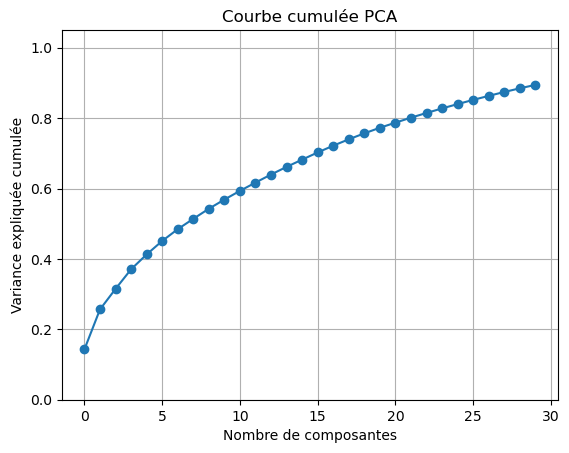

In [15]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Courbe cumulée PCA")
plt.ylim(0, 1.05)
plt.grid()
plt.show()

In [18]:
import scanpy as sc
import anndata as ad
import numpy as np

# 1. créer AnnData avec bon nombre de cellules
adata = ad.AnnData(X=np.zeros((coords.shape[0], 1)))



In [19]:
# 2. stocker embedding
adata.obsm["coords"] = coords



In [20]:
# 3. graphe kNN
sc.pp.neighbors(adata, use_rep="coords", n_neighbors=15)


In [21]:

# 4. Leiden
sc.tl.leiden(
    adata,
    resolution=0.5,
    flavor="igraph",
    n_iterations=2
)


In [ ]:
adata.write('./test/mon_dataset.h5ad')

In [22]:

# 5. UMAP
sc.tl.umap(adata)
adata.write('./test/mon_dataset.h5ad')


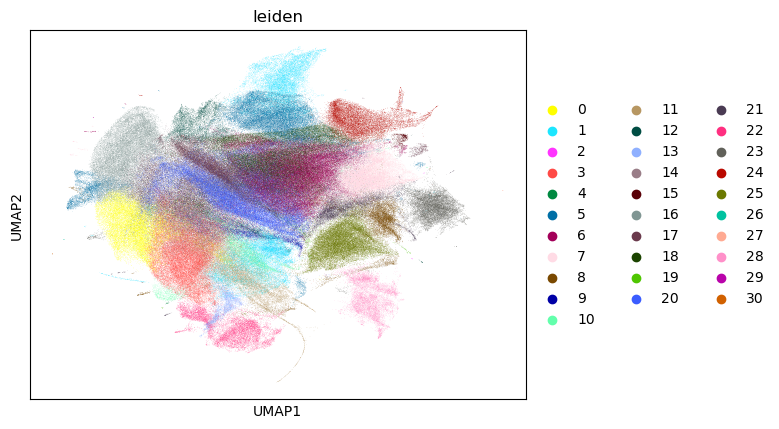

In [23]:
# 6. plot
sc.pl.umap(adata, color="leiden")
adata.write('./test/mon_dataset.h5ad')

In [38]:
import pandas as pd

df_embed = pd.DataFrame(
    adata.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=adata.obs_names
)

df_embed["leiden"] = adata.obs["leiden"].values

In [39]:
df_embed

,UMAP1,UMAP2,leiden
0,-8.277080,4.526409,0
1,4.165807,4.660788,25
2,3.227918,7.029244,25
3,-7.344179,7.606665,20
4,-6.977042,5.212934,0
...,...,...,...
543082,-1.619663,12.698593,17
543083,-2.159161,11.618534,17
543084,1.455573,8.232034,9
543085,-1.209191,11.763626,17


In [42]:
#Enregistre (sans dropna) un data frame avec les nodes et leur label niche, index n'est pas set à zéro
#(ici mets les lignes qui recup big nodes, comme ça sera sans colone patient salmple en doukble)

chemin = f'./test'
save_dir = Path(chemin)

folder = Path("./data/phenograph_clustering/nodes_phenotyped")
files = folder.glob("nodes_*")




all_dfs = []

for file in files:
    
    if "nodes" not in file.name:
        continue

    if file.suffix == ".csv":
        df = pd.read_csv(file)
    elif file.suffix == ".parquet":
        df = pd.read_parquet(file)
    elif file.suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file)
    else:
        continue

    df["source_file"] = file.stem
    all_dfs.append(df)



nodes_cluster_labeled = pd.concat(all_dfs, ignore_index=True)

#nodes_cluster_labeled = pd.concat([big_nodes, var_aggreg], axis=1)


#print(nodes_cluster_labeled[['patient','sample','source_file']])
#nodes_cluster_labeled = nodes_cluster_labeled.reset_index()
#supprime les colonnes en dupliqué et garde que premier qu'il rencontre
#nodes_cluster_labeled = nodes_cluster_labeled.loc[:, ~nodes_cluster_labeled.columns.duplicated()]
nodes_cluster_labeled['Niche'] = df_embed['leiden'].values
print(nodes_cluster_labeled[['source_file',"Niche",'Object']])

# crée tous les dossiers parents si besoin
save_dir.mkdir(parents=True, exist_ok=True)

nodes_cluster_labeled.to_parquet(save_dir/f'nodes_cluster_leiden_labeled.parquet')

                       source_file Niche  Object
0       nodes_patient-04_sample-05     0       1
1       nodes_patient-04_sample-05    25       2
2       nodes_patient-04_sample-05    25       3
3       nodes_patient-04_sample-05    20       4
4       nodes_patient-04_sample-05     0       5
...                            ...   ...     ...
543082  nodes_patient-04_sample-03    17   11659
543083  nodes_patient-04_sample-03    17   11660
543084  nodes_patient-04_sample-03     9   11661
543085  nodes_patient-04_sample-03    17   11662
543086  nodes_patient-04_sample-03    25   11663

[543087 rows x 3 columns]


In [1]:
import scanpy as sc

adata = sc.read_h5ad("mon_dataset.h5ad")